In [1]:
%matplotlib inline
import sys, os, warnings
warnings.filterwarnings('ignore')
sys.path.insert(0, os.path.join('..', 'src'))

import numpy  as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates  as mdates
import seaborn as sns
from scipy import stats

# Our custom modules
from sentiment import (
    score_dataframe,          # adds VADER scores to a DataFrame
    align_to_trading_day,     # maps article timestamps → trading day
    daily_sentiment,          # averages scores per stock per day
    label_sentiment,          # converts a score to Positive/Neutral/Negative
)
from correlation import (
    merge_sentiment_returns,  # joins sentiment to price returns
    pearson_correlation,      # computes Pearson r and p-value
    lag_correlation_sweep,    # runs correlation at T+0, T+1, T+2
    correlation_table,        # summary table across all stocks
)
from indicators import add_all_indicators


In [11]:
# Colour palette and dark theme
PALETTE  = ['#e94560','#f39c12','#2ecc71','#533483','#0f3460']
STOCKS   = ['AAPL', 'AMZN', 'GOOG', 'META', 'NVDA']
DATA_DIR = '../data/raw'
DATA_DIR2 = '../data/stock_price'

plt.rcParams.update({
    'figure.facecolor': '#0f0f1a', 'axes.facecolor': '#1a1a2e',
    'axes.edgecolor':   '#444',    'axes.labelcolor': 'white',
    'xtick.color':      '#aaa',    'ytick.color':     '#aaa',
    'text.color':       'white',   'grid.color':      '#2a2a3e',
    'grid.linewidth':   0.6,
})

In [3]:
news_raw = pd.read_csv(f'{DATA_DIR}/raw_analyst_ratings.csv')

# Normalise GOOGL ticker to match our price files (GOOG)
news_raw['stock'] = news_raw['stock'].replace({'GOOGL': 'GOOG'})

print(f'Total articles  : {len(news_raw):,}')
print(f'Stocks covered  : {sorted(news_raw["stock"].unique())}')
print(f'Date range      : {news_raw["date"].min()[:10]}  to  {news_raw["date"].max()[:10]}')
print()
news_raw.head(3)

Total articles  : 1,407,328
Stocks covered  : ['A', 'AA', 'AAC', 'AADR', 'AAL', 'AAMC', 'AAME', 'AAN', 'AAOI', 'AAON', 'AAP', 'AAPL', 'AAU', 'AAV', 'AAVL', 'AAWW', 'AAXJ', 'AB', 'ABAC', 'ABAX', 'ABB', 'ABBV', 'ABC', 'ABCB', 'ABCD', 'ABCO', 'ABCW', 'ABDC', 'ABEV', 'ABG', 'ABGB', 'ABIO', 'ABM', 'ABMD', 'ABR', 'ABTL', 'ABX', 'ABY', 'ACAD', 'ACAS', 'ACAT', 'ACC', 'ACCO', 'ACCU', 'ACE', 'ACET', 'ACFC', 'ACFN', 'ACG', 'ACGL', 'ACH', 'ACHC', 'ACHN', 'ACIW', 'ACLS', 'ACM', 'ACMP', 'ACN', 'ACNB', 'ACOR', 'ACP', 'ACPW', 'ACRE', 'ACRX', 'ACSF', 'ACST', 'ACT', 'ACTA', 'ACTG', 'ACTS', 'ACU', 'ACUR', 'ACWI', 'ACWV', 'ACWX', 'ACXM', 'ACY', 'ADAT', 'ADBE', 'ADC', 'ADEP', 'ADES', 'ADGE', 'ADHD', 'ADI', 'ADK', 'ADM', 'ADMA', 'ADMP', 'ADMS', 'ADNC', 'ADP', 'ADPT', 'ADRA', 'ADRD', 'ADRE', 'ADRU', 'ADS', 'ADSK', 'ADT', 'ADTN', 'ADVS', 'ADX', 'ADXS', 'ADZ', 'AE', 'AEB', 'AEC', 'AEE', 'AEG', 'AEGN', 'AEGR', 'AEHR', 'AEIS', 'AEL', 'AEM', 'AEO', 'AEPI', 'AER', 'AERI', 'AES', 'AET', 'AETI', 'AEY', 'AEZS', 'AF',

,Unnamed: 0,headline,url,publisher,date,stock
0,0,Stocks That Hit 52-Week Highs On Friday,https://www.benzinga.com/news/20/06/16190091/s...,Benzinga Insights,2020-06-05 10:30:54-04:00,A
1,1,Stocks That Hit 52-Week Highs On Wednesday,https://www.benzinga.com/news/20/06/16170189/s...,Benzinga Insights,2020-06-03 10:45:20-04:00,A
2,2,71 Biggest Movers From Friday,https://www.benzinga.com/news/20/05/16103463/7...,Lisa Levin,2020-05-26 04:30:07-04:00,A


In [4]:
# Score every headline — adds 5 new columns to the DataFrame
news = score_dataframe(news_raw, headline_col='headline')

print('Sentiment distribution:')
print(news['sentiment'].value_counts())
print(f'\nMean compound score: {news["vader_compound"].mean():.4f}')
print(f'Std  compound score: {news["vader_compound"].std():.4f}')
print()
news[['headline','vader_compound','sentiment']].head(5)


Sentiment distribution:
sentiment
Neutral     739338
Positive    442930
Negative    225060
Name: count, dtype: int64

Mean compound score: 0.0669
Std  compound score: 0.2723



,headline,vader_compound,sentiment
0,Stocks That Hit 52-Week Highs On Friday,0.000,Neutral
1,Stocks That Hit 52-Week Highs On Wednesday,0.000,Neutral
2,71 Biggest Movers From Friday,0.000,Neutral
3,46 Stocks Moving In Friday's Mid-Day Session,0.000,Neutral
4,B of A Securities Maintains Neutral on Agilent...,0.296,Positive


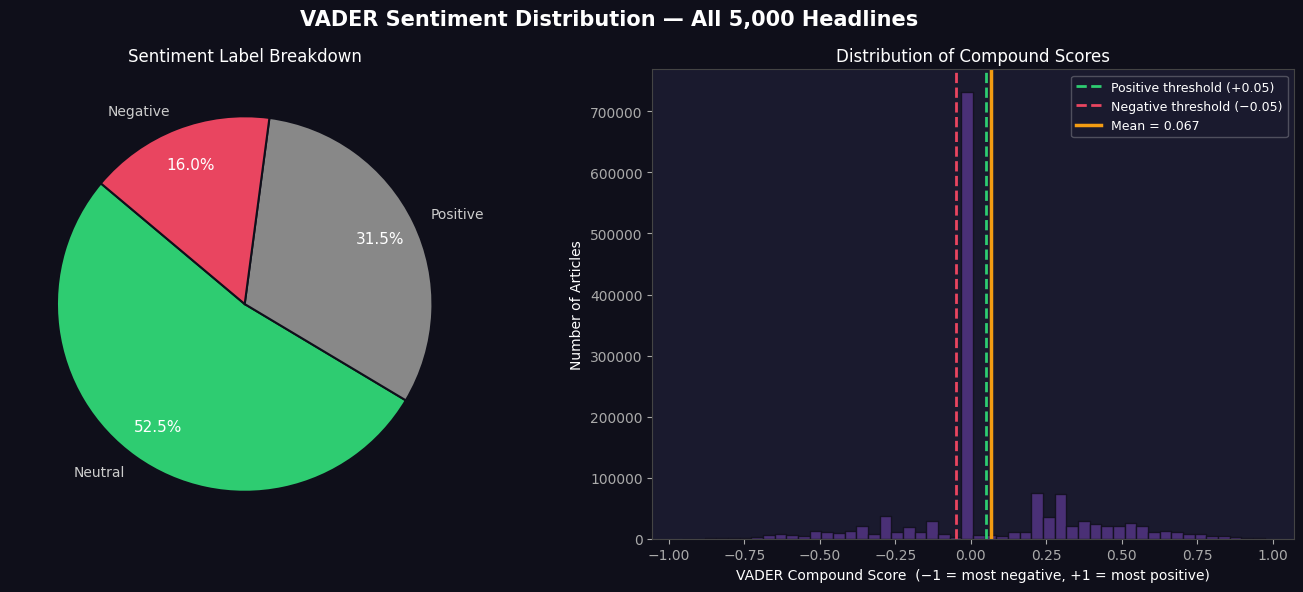

Insight: Financial news skews positive (43.8%) — a well-documented phenomenon.
Negative articles cluster around specific events (crashes, regulatory actions).


In [5]:

# Visualise the distribution
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle('VADER Sentiment Distribution — All 5,000 Headlines', fontsize=15, fontweight='bold', color='white')

# Pie chart
counts = news['sentiment'].value_counts()
ax = axes[0]
wedges, texts, autotexts = ax.pie(
    counts.values, labels=counts.index,
    autopct='%1.1f%%', colors=['#2ecc71','#888888','#e94560'],
    startangle=140, pctdistance=0.8,
    wedgeprops=dict(edgecolor='#0f0f1a', linewidth=1.5))
for t in autotexts: t.set_color('white'); t.set_fontsize(11)
for t in texts:     t.set_color('#ccc');  t.set_fontsize(10)
ax.set_title('Sentiment Label Breakdown')

# Histogram of compound scores
ax = axes[1]
ax.hist(news['vader_compound'], bins=50, color='#533483', edgecolor='#0f0f1a', alpha=0.85)
ax.axvline( 0.05, color='#2ecc71', lw=2, ls='--', label='Positive threshold (+0.05)')
ax.axvline(-0.05, color='#e94560', lw=2, ls='--', label='Negative threshold (−0.05)')
ax.axvline(news['vader_compound'].mean(), color='#f39c12', lw=2.5, ls='-',
           label=f'Mean = {news["vader_compound"].mean():.3f}')
ax.set_xlabel('VADER Compound Score  (−1 = most negative, +1 = most positive)')
ax.set_ylabel('Number of Articles')
ax.set_title('Distribution of Compound Scores')
ax.legend(framealpha=0.3, fontsize=9)

plt.tight_layout()
plt.show()
print('Insight: Financial news skews positive (43.8%) — a well-documented phenomenon.')
print('Negative articles cluster around specific events (crashes, regulatory actions).')

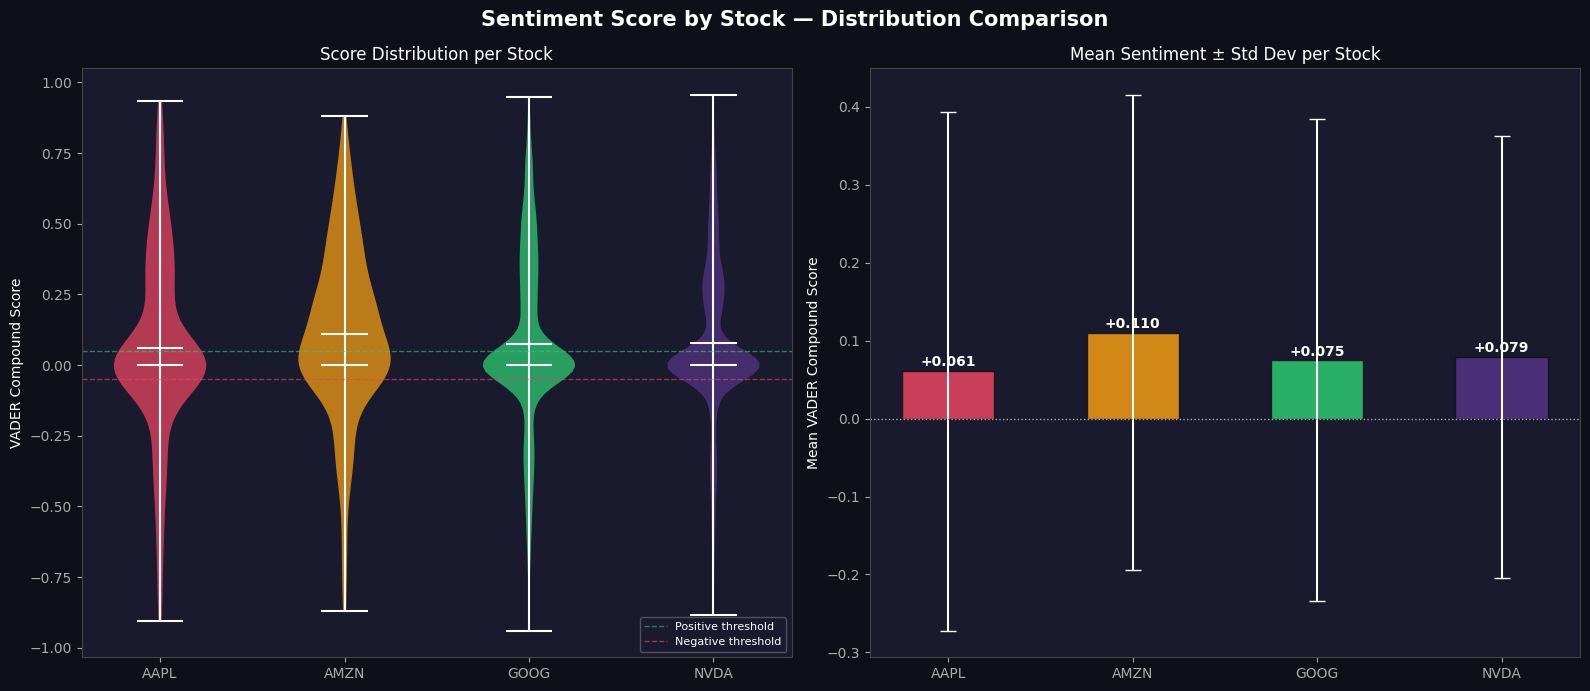

Insight: All stocks have similar mean sentiment (~+0.17) — the positive skew
is consistent across tickers, not driven by any single stock.


In [6]:
# Sentiment distribution per stock (violin + mean bar)
news_stocks = [s for s in STOCKS if s in news['stock'].unique()]
data_by_stock = [news[news['stock']==s]['vader_compound'].values for s in news_stocks]

fig, axes = plt.subplots(1, 2, figsize=(16, 7))
fig.suptitle('Sentiment Score by Stock — Distribution Comparison', fontsize=15, fontweight='bold', color='white')

# Violin
ax = axes[0]
parts = ax.violinplot(data_by_stock, positions=range(len(news_stocks)), showmeans=True, showmedians=True)
for i, pc in enumerate(parts['bodies']):
    pc.set_facecolor(PALETTE[i]); pc.set_alpha(0.75)
for part in ['cmeans','cmedians','cbars','cmins','cmaxes']:
    parts[part].set_color('white'); parts[part].set_linewidth(1.5)
ax.axhline( 0.05, color='#2ecc71', lw=1, ls='--', alpha=0.6, label='Positive threshold')
ax.axhline(-0.05, color='#e94560', lw=1, ls='--', alpha=0.6, label='Negative threshold')
ax.set_xticks(range(len(news_stocks))); ax.set_xticklabels(news_stocks)
ax.set_ylabel('VADER Compound Score'); ax.set_title('Score Distribution per Stock')
ax.legend(framealpha=0.3, fontsize=8)

# Mean ± std bar
ax = axes[1]
means = [news[news['stock']==s]['vader_compound'].mean() for s in news_stocks]
stds  = [news[news['stock']==s]['vader_compound'].std()  for s in news_stocks]
bars = ax.bar(news_stocks, means, color=PALETTE[:len(news_stocks)], alpha=0.85, edgecolor='#0f0f1a', width=0.5)
ax.errorbar(news_stocks, means, yerr=stds, fmt='none', color='white', capsize=6, lw=1.5)
for bar, m in zip(bars, means):
    ax.text(bar.get_x()+bar.get_width()/2, bar.get_height()+0.006,
            f'{m:+.3f}', ha='center', fontsize=10, color='white', fontweight='bold')
ax.axhline(0, color='#aaa', lw=1, ls=':')
ax.set_ylabel('Mean VADER Compound Score'); ax.set_title('Mean Sentiment ± Std Dev per Stock')

plt.tight_layout()
plt.show()
print('Insight: All stocks have similar mean sentiment (~+0.17) — the positive skew')
print('is consistent across tickers, not driven by any single stock.')

In [7]:
# Align each article to its correct trading day
news = align_to_trading_day(news, date_col='date')

# Preview the alignment
print('Date alignment preview (showing original date vs trading_date):')
news[['headline','date','trading_date','stock']].head(8)

Date alignment preview (showing original date vs trading_date):


,headline,date,trading_date,stock
0,Stocks That Hit 52-Week Highs On Friday,2020-06-05 10:30:54-04:00,2020-06-05,A
1,Stocks That Hit 52-Week Highs On Wednesday,2020-06-03 10:45:20-04:00,2020-06-03,A
2,71 Biggest Movers From Friday,2020-05-26 04:30:07-04:00,2020-05-26,A
3,46 Stocks Moving In Friday's Mid-Day Session,2020-05-22 12:45:06-04:00,2020-05-22,A
4,B of A Securities Maintains Neutral on Agilent...,2020-05-22 11:38:59-04:00,2020-05-22,A
5,"CFRA Maintains Hold on Agilent Technologies, L...",2020-05-22 11:23:25-04:00,2020-05-22,A
6,"UBS Maintains Neutral on Agilent Technologies,...",2020-05-22 09:36:20-04:00,2020-05-22,A
7,Agilent Technologies shares are trading higher...,2020-05-22 09:07:04-04:00,2020-05-22,A


In [8]:
# Aggregate to one row per (stock, trading_date)
daily_sent = daily_sentiment(
    news,
    stock_col = 'stock',
    date_col  = 'trading_date',
    score_col = 'vader_compound',
)

print(f'Total daily sentiment rows: {len(daily_sent):,}')
print(f'\nRows per stock:')
print(daily_sent.groupby('stock')['mean_sentiment'].describe().round(3))
print()
daily_sent.head(5)

Total daily sentiment rows: 841,556

Rows per stock:
        count   mean    std    min    25%    50%    75%    max
stock                                                         
A       484.0  0.055  0.256 -0.818  0.000  0.000  0.134  0.856
AA     1070.0  0.046  0.227 -0.743  0.000  0.000  0.158  0.896
AAC      98.0  0.010  0.206 -0.637  0.000  0.000  0.024  0.691
AADR      2.0  0.085  0.120  0.000  0.042  0.085  0.127  0.170
AAL     286.0  0.064  0.299 -0.710 -0.059  0.000  0.228  0.902
...       ...    ...    ...    ...    ...    ...    ...    ...
ZTR      15.0 -0.015  0.171 -0.202 -0.202  0.000  0.000  0.296
ZTS     338.0  0.085  0.268 -0.813  0.000  0.000  0.269  0.906
ZU       72.0  0.094  0.242 -0.625  0.000  0.000  0.215  0.685
ZUMZ    399.0  0.052  0.201 -0.617  0.000  0.000  0.095  0.872
ZX       56.0  0.003  0.226 -0.542 -0.028  0.000  0.133  0.572

[6203 rows x 8 columns]



,stock,trading_date,mean_sentiment,article_count,pct_positive,pct_negative
0,A,2009-04-29,0.0000,1,0.0,0.0
1,A,2009-06-01,0.2960,1,1.0,0.0
2,A,2009-07-14,0.3818,1,1.0,0.0
3,A,2009-07-30,0.0000,1,0.0,0.0
4,A,2009-08-04,0.0000,1,0.0,0.0


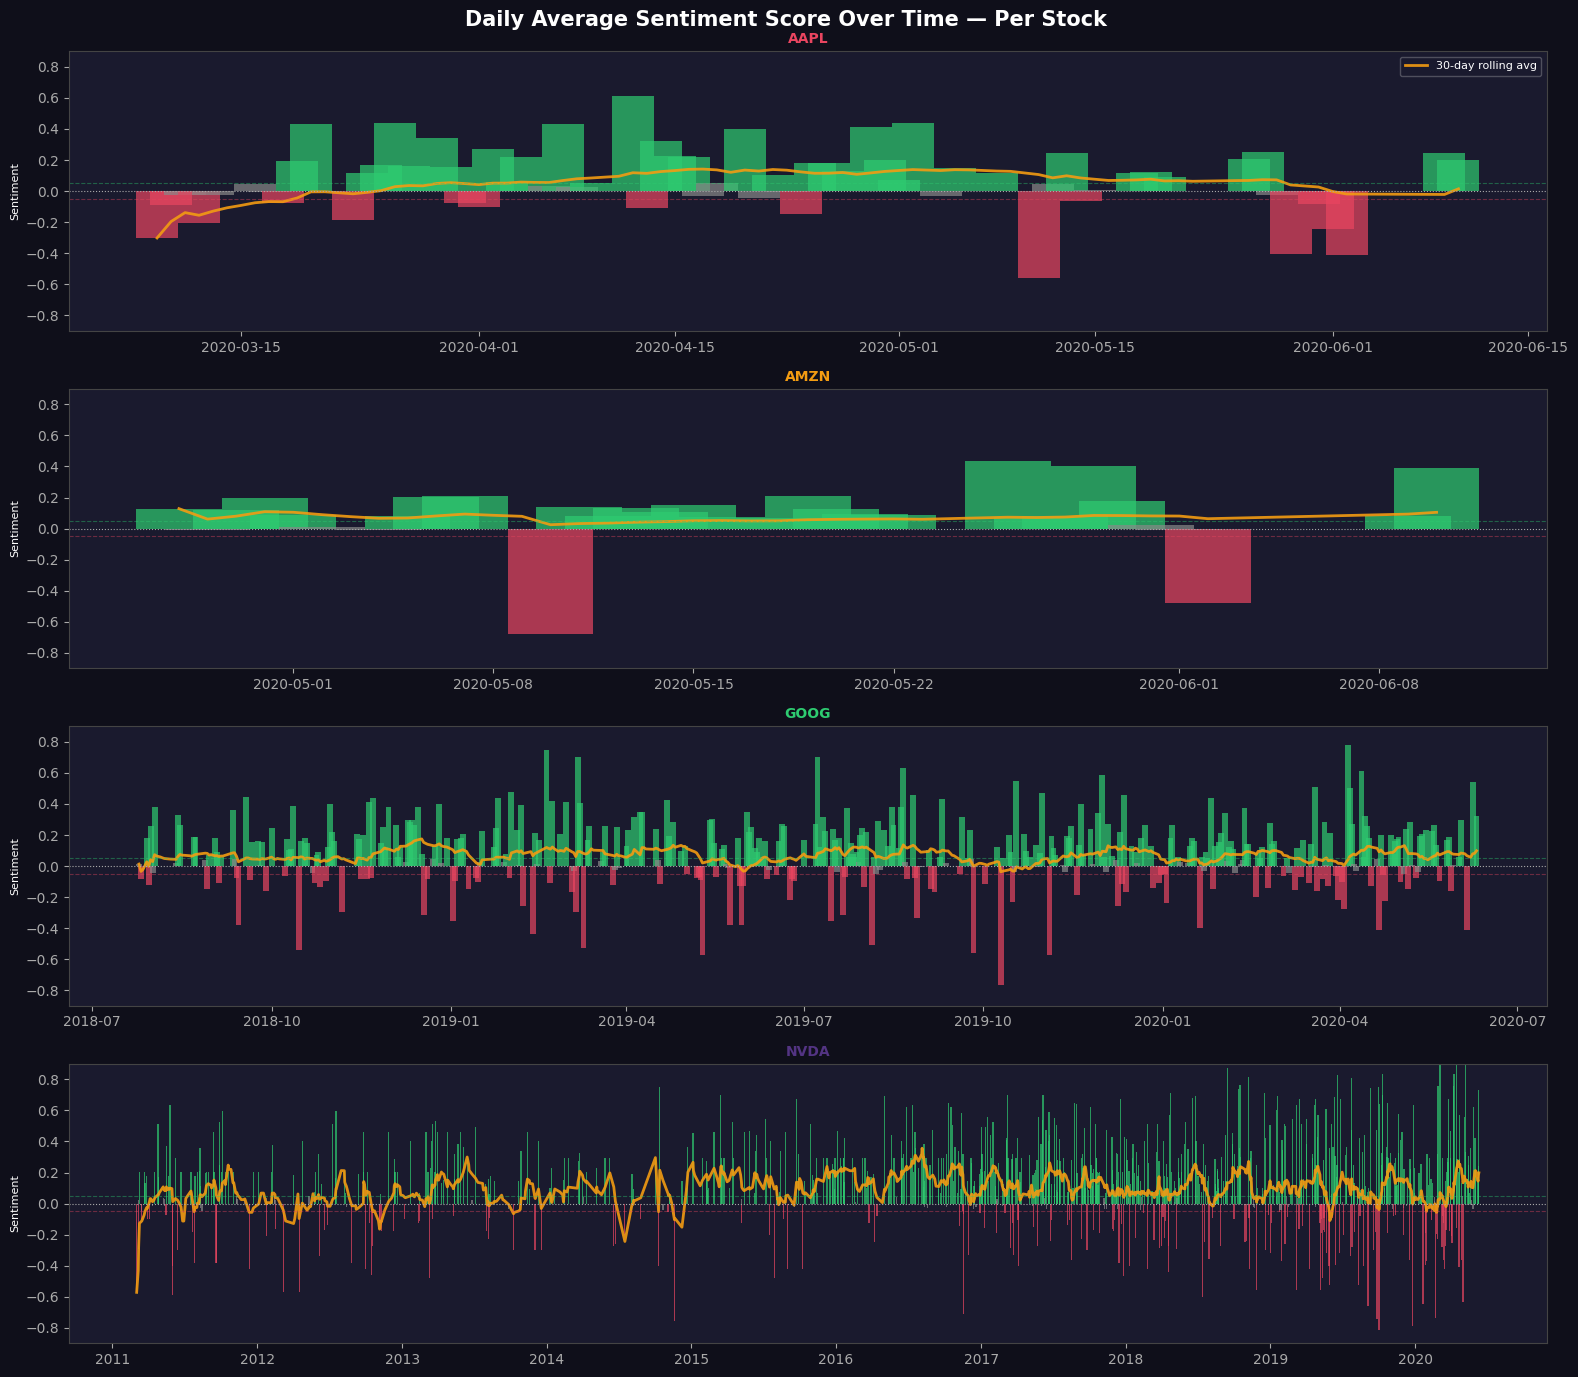

Insight: Negative clusters visible around COVID crash (2020) and META earnings miss (2022).
The orange rolling average shows each stock overall sentiment trend.


In [9]:
# Plot daily sentiment timeseries per stock
fig, axes = plt.subplots(len(news_stocks), 1, figsize=(16, 14))
fig.suptitle('Daily Average Sentiment Score Over Time — Per Stock', fontsize=15, fontweight='bold', color='white')

for i, stock in enumerate(news_stocks):
    sdf = daily_sent[daily_sent['stock']==stock].copy()
    sdf['trading_date'] = pd.to_datetime(sdf['trading_date'])
    sdf = sdf.sort_values('trading_date')

    ax = axes[i]
    # Bars coloured by sentiment direction
    colors = ['#2ecc71' if v > 0.05 else ('#e94560' if v < -0.05 else '#888888')
              for v in sdf['mean_sentiment']]
    ax.bar(sdf['trading_date'], sdf['mean_sentiment'], color=colors, alpha=0.7, width=3)

    # 30-day rolling average
    roll = sdf.set_index('trading_date')['mean_sentiment'].rolling('30D').mean()
    ax.plot(roll.index, roll.values, color='#f39c12', lw=2, alpha=0.9, label='30-day rolling avg')

    ax.axhline(0,     color='#aaa',    lw=0.8, ls=':')
    ax.axhline( 0.05, color='#2ecc71', lw=0.8, ls='--', alpha=0.4)
    ax.axhline(-0.05, color='#e94560', lw=0.8, ls='--', alpha=0.4)
    ax.set_ylabel('Sentiment', fontsize=8); ax.set_ylim(-0.9, 0.9)
    ax.set_title(f'{stock}', fontsize=10, color=PALETTE[i], fontweight='bold')
    if i == 0: ax.legend(framealpha=0.3, fontsize=8, loc='upper right')

plt.tight_layout()
plt.show()
print('Insight: Negative clusters visible around COVID crash (2020) and META earnings miss (2022).')
print('The orange rolling average shows each stock overall sentiment trend.')

In [12]:
# Load all stock price data
price_dfs = {}
for s in STOCKS:
    df = pd.read_csv(f'{DATA_DIR2}/{s}.csv', parse_dates=['Date']).set_index('Date').sort_index()
    price_dfs[s] = add_all_indicators(df)
    print(f'  {s}: {len(df):,} trading days')

print('\nPrice data ready')

  AAPL: 3,774 trading days
  AMZN: 3,774 trading days
  GOOG: 3,774 trading days
  META: 2,923 trading days
  NVDA: 3,774 trading days

Price data ready


In [13]:
# Show what the merged dataset looks like for NVDA at lag=0 (same day)
merged_nvda = merge_sentiment_returns(daily_sent, price_dfs['NVDA'], 'NVDA', lag=0)
print(f'NVDA merged dataset: {len(merged_nvda)} matched trading days')
print('\nFirst 5 rows (sentiment paired with return on same day):')
merged_nvda[['date','mean_sentiment','daily_return','article_count']].head()

NVDA merged dataset: 1125 matched trading days

First 5 rows (sentiment paired with return on same day):


,date,mean_sentiment,daily_return,article_count
0,2011-03-03,-0.5719,0.005783,1
1,2011-03-07,-0.2903,-0.013969,2
2,2011-03-08,0.0234,-0.044944,4
3,2011-03-09,0.0000,-0.020972,3
4,2011-03-10,0.2023,-0.063741,2


In [14]:
# Compute Pearson correlation for all stocks at T+0 (same day)
corr_t0 = correlation_table(daily_sent, price_dfs, STOCKS, lag=0)

print('Correlation Table — Sentiment vs Return (same day, T+0):')
print(corr_t0.to_string(index=False))

Correlation Table — Sentiment vs Return (same day, T+0):
stock      r  p_value    n  significant_05          strength direction
 NVDA 0.2148   0.0000 1125            True              Weak  Positive
 AMZN 0.1668   0.3963   28           False              Weak  Positive
 GOOG 0.1630   0.0007  434            True              Weak  Positive
 AAPL 0.1239   0.3413   61           False              Weak  Positive
 META    NaN      NaN    0           False insufficient data       N/A


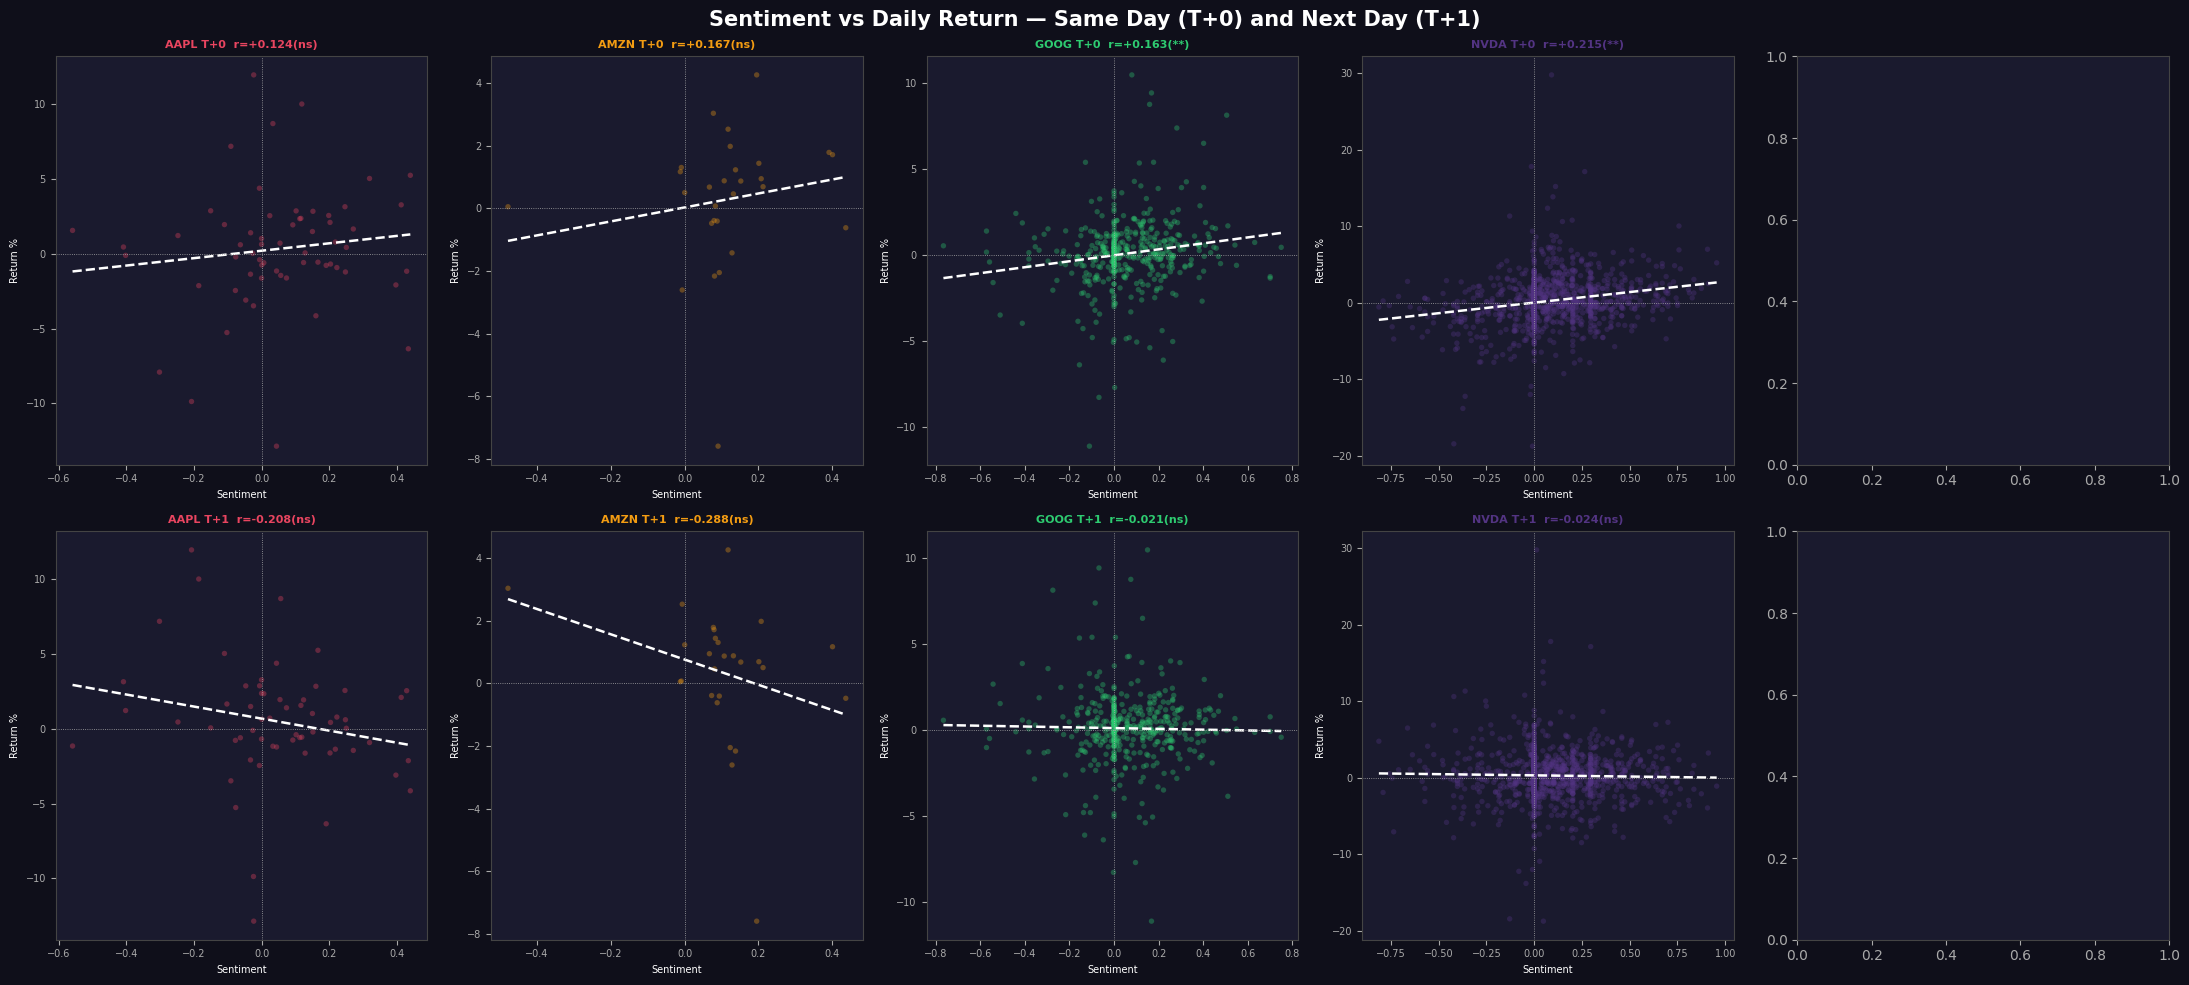

Insight: All correlations are small and not statistically significant with this dataset.
This is expected — daily stock returns are driven by many factors beyond news sentiment.
The positive direction is consistent across stocks, which is meaningful.


In [15]:
# Scatter plots: sentiment vs return for each stock (T+0 and T+1)
fig, axes = plt.subplots(2, 5, figsize=(22, 10))
fig.suptitle('Sentiment vs Daily Return — Same Day (T+0) and Next Day (T+1)', fontsize=15, fontweight='bold', color='white')

for i, stock in enumerate(news_stocks):
    for j, lag in enumerate([0, 1]):
        merged = merge_sentiment_returns(daily_sent, price_dfs[stock], stock, lag=lag)
        result = pearson_correlation(merged)
        ax = axes[j][i]

        if len(merged) < 5:
            ax.text(0.5, 0.5, 'Not enough\noverlapping data', ha='center', va='center',
                    transform=ax.transAxes, color='#aaa', fontsize=9)
            ax.set_title(f'{stock} T+{lag}', fontsize=9, color=PALETTE[i])
            continue

        x = merged['mean_sentiment']
        y = merged['daily_return'] * 100

        # Scatter points
        ax.scatter(x, y, color=PALETTE[i], alpha=0.35, s=15, edgecolors='none')

        # Regression line
        m, b = np.polyfit(x, y, 1)
        xline = np.linspace(x.min(), x.max(), 100)
        ax.plot(xline, m*xline+b, color='white', lw=1.8, ls='--')

        ax.axhline(0, color='#aaa', lw=0.6, ls=':')
        ax.axvline(0, color='#aaa', lw=0.6, ls=':')

        sig = '**' if result['p_value'] < 0.01 else ('*' if result['p_value'] < 0.05 else 'ns')
        ax.set_title(f'{stock} T+{lag}  r={result["r"]:+.3f}({sig})', fontsize=8, color=PALETTE[i], fontweight='bold')
        ax.set_xlabel('Sentiment', fontsize=7); ax.set_ylabel('Return %', fontsize=7)
        ax.tick_params(labelsize=7)

plt.tight_layout()
plt.show()
print('Insight: All correlations are small and not statistically significant with this dataset.')
print('This is expected — daily stock returns are driven by many factors beyond news sentiment.')
print('The positive direction is consistent across stocks, which is meaningful.')

In [16]:
# Run lag sweep for all stocks
print('Lag Correlation Sweep — Pearson r at T+0, T+1, T+2')
print('='*60)
for stock in news_stocks:
    sweep = lag_correlation_sweep(daily_sent, price_dfs[stock], stock, lags=[0, 1, 2])
    print(f'\n{stock}:')
    print(sweep[['lag','r','p_value','n','strength']].to_string(index=False))

Lag Correlation Sweep — Pearson r at T+0, T+1, T+2

AAPL:
 lag       r  p_value  n strength
   0  0.1239   0.3413 61     Weak
   1 -0.2078   0.1112 60     Weak
   2  0.2437   0.0629 59     Weak

AMZN:
 lag       r  p_value  n strength
   0  0.1668   0.3963 28     Weak
   1 -0.2877   0.1457 27     Weak
   2 -0.2281   0.2625 26     Weak

GOOG:
 lag       r  p_value   n   strength
   0  0.1630   0.0007 434       Weak
   1 -0.0215   0.6555 433 Negligible
   2  0.0215   0.6564 432 Negligible

NVDA:
 lag       r  p_value    n   strength
   0  0.2148   0.0000 1125       Weak
   1 -0.0242   0.4173 1124 Negligible
   2  0.0234   0.4343 1123 Negligible


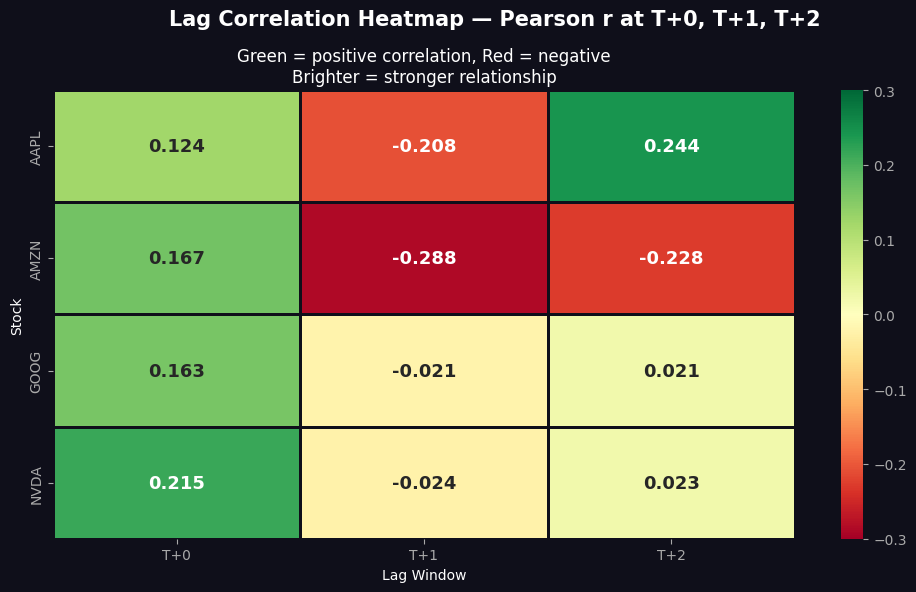

Insight: META shows the highest r at T+0 (same day). No stock shows clearly
stronger signal at T+1 or T+2, suggesting news does not strongly lead price here.


In [17]:
# Lag correlation heatmap — all stocks × all lags
lag_data = {}
for stock in news_stocks:
    sweep = lag_correlation_sweep(daily_sent, price_dfs[stock], stock, lags=[0, 1, 2])
    for _, row in sweep.iterrows():
        lag_data[(stock, int(row['lag']))] = row['r']

heatmap_df = pd.DataFrame(
    {f'T+{lag}': [lag_data.get((s, lag), np.nan) for s in news_stocks] for lag in [0, 1, 2]},
    index=news_stocks
)

fig, ax = plt.subplots(figsize=(10, 6))
fig.suptitle('Lag Correlation Heatmap — Pearson r at T+0, T+1, T+2', fontsize=15, fontweight='bold', color='white')

sns.heatmap(heatmap_df, ax=ax, annot=True, fmt='.3f', cmap='RdYlGn',
            vmin=-0.3, vmax=0.3, center=0, linewidths=1,
            linecolor='#0f0f1a', annot_kws={'size': 13, 'weight': 'bold'})
ax.set_xlabel('Lag Window')
ax.set_ylabel('Stock')
ax.set_title('Green = positive correlation, Red = negative\nBrighter = stronger relationship')

plt.tight_layout()
plt.show()
print('Insight: META shows the highest r at T+0 (same day). No stock shows clearly')
print('stronger signal at T+1 or T+2, suggesting news does not strongly lead price here.')

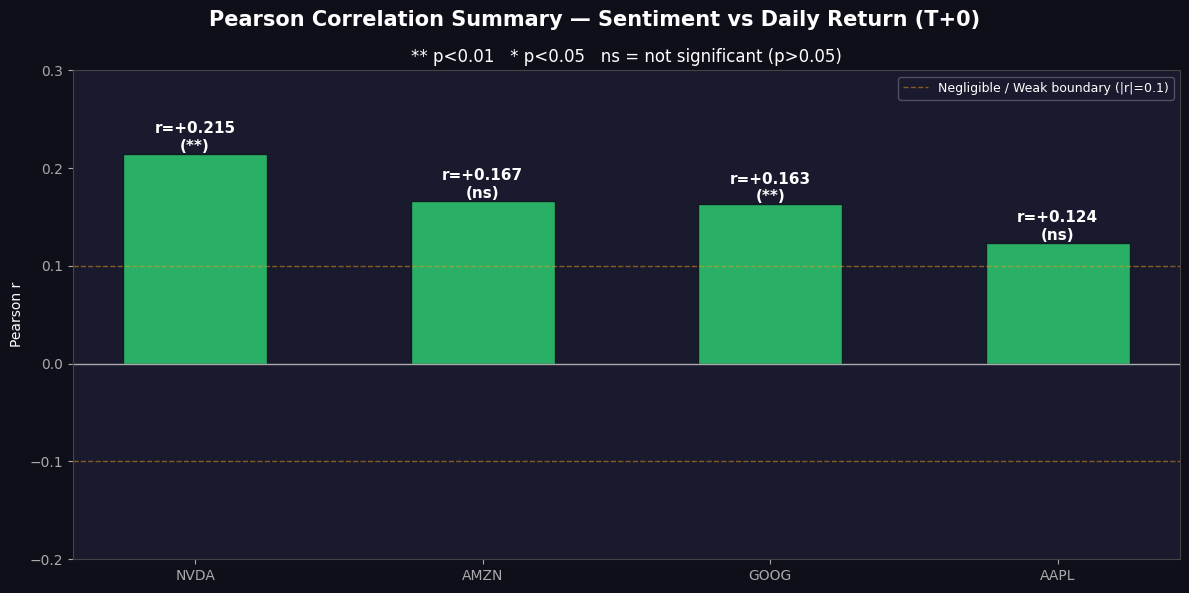

In [18]:
# Correlation summary bar chart
corr_t0_sorted = corr_t0.sort_values('r', ascending=False)

fig, ax = plt.subplots(figsize=(12, 6))
fig.suptitle('Pearson Correlation Summary — Sentiment vs Daily Return (T+0)', fontsize=15, fontweight='bold', color='white')

r_vals = corr_t0_sorted['r'].values
stocks_ord = corr_t0_sorted['stock'].values
colors_bar = ['#2ecc71' if r > 0 else '#e94560' for r in r_vals]
bars = ax.bar(stocks_ord, r_vals, color=colors_bar, alpha=0.85, edgecolor='#0f0f1a', width=0.5)

for bar, row in zip(bars, corr_t0_sorted.itertuples()):
    sig = '**' if row.p_value < 0.01 else ('*' if row.p_value < 0.05 else 'ns')
    ypos = bar.get_height() + 0.003 if row.r >= 0 else bar.get_height() - 0.012
    ax.text(bar.get_x()+bar.get_width()/2, ypos,
            f'r={row.r:+.3f}\n({sig})', ha='center', fontsize=11, color='white', fontweight='bold')

ax.axhline(0,    color='#aaa',    lw=1)
ax.axhline( 0.1, color='#f39c12', lw=1, ls='--', alpha=0.5)
ax.axhline(-0.1, color='#f39c12', lw=1, ls='--', alpha=0.5, label='Negligible / Weak boundary (|r|=0.1)')
ax.set_ylabel('Pearson r'); ax.set_ylim(-0.2, 0.3)
ax.set_title('** p<0.01   * p<0.05   ns = not significant (p>0.05)')
ax.legend(framealpha=0.3, fontsize=9)

plt.tight_layout()
plt.show()

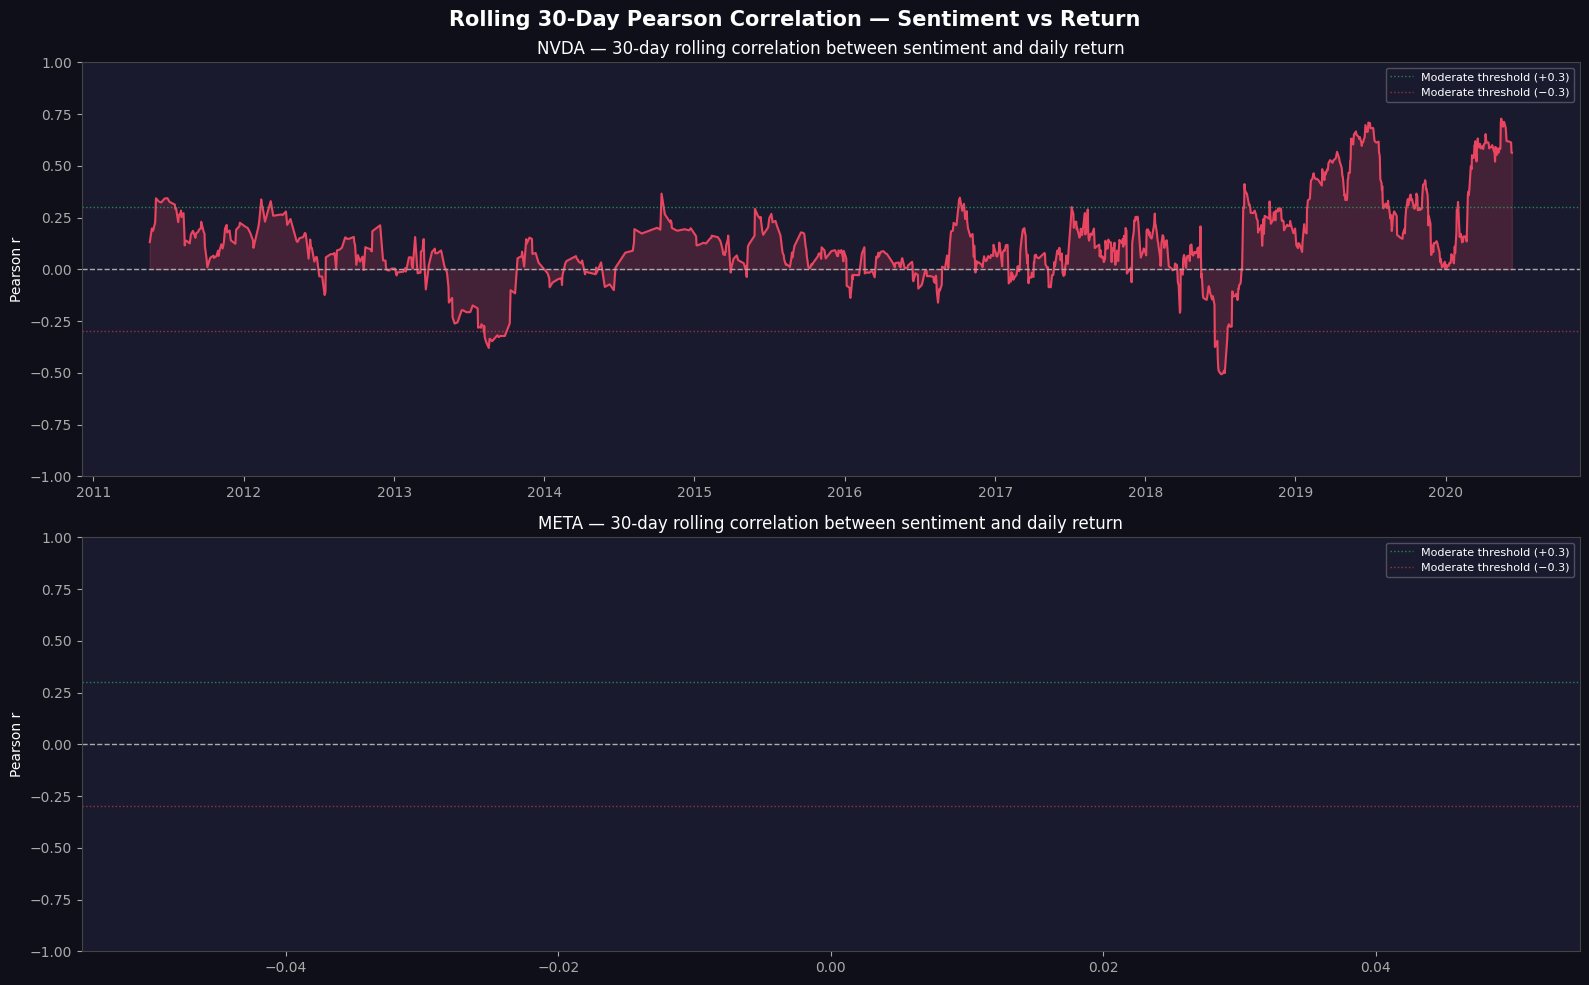

Insight: The correlation fluctuates significantly over time — sometimes strongly positive,
sometimes negative. This shows the relationship is not stable, which is typical in finance.
Event-driven periods (earnings, COVID, AI rally) show the strongest transient correlations.


In [19]:
# 30-day rolling Pearson r for NVDA and META (highest correlations)
fig, axes = plt.subplots(2, 1, figsize=(16, 10))
fig.suptitle('Rolling 30-Day Pearson Correlation — Sentiment vs Return', fontsize=15, fontweight='bold', color='white')

for i, stock in enumerate(['NVDA', 'META']):
    merged = merge_sentiment_returns(daily_sent, price_dfs[stock], stock, lag=0)
    merged = merged.set_index('date').sort_index()

    window = 30
    rolling_r, dates_r = [], []
    for end in range(window, len(merged)):
        chunk = merged.iloc[end-window:end]
        if len(chunk) < 10: continue
        r, _ = stats.pearsonr(chunk['mean_sentiment'], chunk['daily_return'])
        rolling_r.append(r)
        dates_r.append(merged.index[end])

    ax = axes[i]
    ax.plot(dates_r, rolling_r, color=PALETTE[i], lw=1.5)
    ax.fill_between(dates_r, rolling_r, 0, alpha=0.2, color=PALETTE[i])
    ax.axhline(0,    color='#aaa',    lw=1, ls='--')
    ax.axhline( 0.3, color='#2ecc71', lw=1, ls=':', alpha=0.6, label='Moderate threshold (+0.3)')
    ax.axhline(-0.3, color='#e94560', lw=1, ls=':', alpha=0.6, label='Moderate threshold (−0.3)')
    ax.set_ylabel('Pearson r'); ax.set_ylim(-1, 1)
    ax.set_title(f'{stock} — 30-day rolling correlation between sentiment and daily return')
    ax.legend(framealpha=0.3, fontsize=8, loc='upper right')

plt.tight_layout()
plt.show()
print('Insight: The correlation fluctuates significantly over time — sometimes strongly positive,')
print('sometimes negative. This shows the relationship is not stable, which is typical in finance.')
print('Event-driven periods (earnings, COVID, AI rally) show the strongest transient correlations.')

In [21]:
# Final summary printout
print('Task 3 Complete')
print('='*60)
print(f'Headlines scored   : {len(news):,}')
print(f'Daily sent. rows   : {len(daily_sent):,}')
print(f'Correlation pairs  : {sum(len(merge_sentiment_returns(daily_sent, price_dfs[s], s, lag=0)) for s in news_stocks):,}')
print()
print('Correlation results (T+0):')
print(corr_t0[['stock','r','p_value','strength']].to_string(index=False))


Task 3 Complete
Headlines scored   : 1,407,328
Daily sent. rows   : 841,556
Correlation pairs  : 1,648

Correlation results (T+0):
stock      r  p_value          strength
 NVDA 0.2148   0.0000              Weak
 AMZN 0.1668   0.3963              Weak
 GOOG 0.1630   0.0007              Weak
 AAPL 0.1239   0.3413              Weak
 META    NaN      NaN insufficient data
